## Authorship

- **Course / code author:** Xinze Li  
- **Tutorial article:** Xinze Li, Fanfan Lin, Juan J. Rodríguez-Andina, Sergio Vazquez, Homer Alan Mantooth, Leopoldo García Franquelo, "Fundamentals of Artificial Intelligences for Power Electronics," *IEEE Transactions on Industrial Electronics*, 2026.

*These learning resources are still under active refinement; notebooks, data, and documentation may change.*

---



#### LTspice automation
* Use PyLTSpice to enumerate simulation parameters and retrieve data

In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from PyLTSpice import SimRunner
    from PyLTSpice import SpiceEditor
    from PyLTSpice import RawRead
except ModuleNotFoundError as e:
    print(f"ModuleNotFoundError: {e}")
    print("Please ensure that the 'PyLTSpice' package is installed and accessible.")
    SimRunner = None
    SpiceEditor = None
    RawRead = None

# --- Settings ---
asc_file = "DPT_Test_Stand_HB_automate.asc"  # Your LTspice schematic file
ltspice_path = r"D:\LTspice\LTspice.exe"  # Adjust this
output_folder = './temp'

# --- Sweep parameters ---
Lbus_vals = [5e-9, 10e-9, 20e-9]
Rg_vals = [0.5, 1, 2]
RgIcOn_vals = [0.3, 0.5, 1.0]
RgIcOff_vals = [0.3, 0.5, 1.0]

sweeps = list(itertools.product(Lbus_vals, Rg_vals, RgIcOn_vals, RgIcOff_vals))

# --- Results container
results = []

def check_file_exists(filepath, description="file"):
    if not os.path.isfile(filepath):
        print(f"[ERROR] The specified {description} does not exist: {filepath}")
        return False
    return True

if SimRunner is not None and SpiceEditor is not None and RawRead is not None:
    # Check if LTspice executable exists
    if not check_file_exists(ltspice_path, "LTspice executable"):
        print("Simulation aborted: LTspice executable not found.")
    # Check if schematic file exists
    elif not check_file_exists(asc_file, "LTspice schematic (.asc)"):
        print("Simulation aborted: Schematic file not found.")
    else:
        # Setup SimRunner and create netlist
        LTC = None
        try:
            LTC = SimRunner(output_folder=output_folder, simulator=ltspice_path)
            LTC.create_netlist(asc_file)
        except Exception as e:
            print(f"[!] Error during netlist creation: {e}")
            LTC = None

        if LTC is not None:
            netlist_file = os.path.splitext(asc_file)[0] + ".net"
            if not check_file_exists(netlist_file, "netlist file"):
                print("Simulation aborted: Netlist file was not created.")
            else:
                netlist = SpiceEditor(netlist_file)

                for idx, (Lbus, Rg, RgIcOn, RgIcOff) in enumerate(sweeps):
                    print(f"[{idx+1}/{len(sweeps)}] Running Lbus={Lbus}, Rg={Rg}, RgIcOn={RgIcOn}, RgIcOff={RgIcOff}")

                    # Set parameters for this sweep
                    netlist.set_parameters(Lbus=Lbus, Rg=Rg, RgIcOn=RgIcOn, RgIcOff=RgIcOff)

                    # Run simulation
                    try:
                        LTC.run(netlist)
                    except Exception as e:
                        print(f"[!] Error running simulation: {e}")
                        break

                # Collect results
                for raw_file, log_file in LTC:
                    try:
                        raw = RawRead(raw_file)
                        sweep_idx = len(results)
                        if sweep_idx < len(sweeps):
                            Lbus, Rg, RgIcOn, RgIcOff = sweeps[sweep_idx]
                        else:
                            Lbus = Rg = RgIcOn = RgIcOff = np.nan

                        i_load_peak = np.nan
                        vds_peak = np.nan
                        vds_steady = 800 # 800 V is the steady-state voltage
                        vds_overshoot = np.nan
                        try:
                            i_load = raw.get_trace("I(Loadind)")
                            v_high = raw.get_trace("V(high)")
                            v_mid = raw.get_trace("V(mid)")
                            time = raw.get_trace("time")

                            # Get the waveform (assume single step)
                            i_load_wave = i_load.get_wave()
                            v_high_wave = v_high.get_wave()
                            v_mid_wave = v_mid.get_wave()
                            vds_wave = v_high_wave - v_mid_wave

                            i_load_peak = np.max(i_load_wave)
                            vds_peak = np.max(vds_wave)
                            vds_overshoot = vds_peak - vds_steady
                        except Exception as e:
                            print(f"[!] Failed to read I(Loadind) or V(high)-V(mid): {e}")

                        results.append({
                            "Lbus": Lbus,
                            "Rg": Rg,
                            "RgIcOn": RgIcOn,
                            "RgIcOff": RgIcOff,
                            "I_load_peak_A": i_load_peak,
                            "Vds_peak_V": vds_peak,
                            "Vds_overshoot_V": vds_overshoot
                        })
                    except Exception as e:
                        print(f"[!] Error processing simulation result: {e}")

                # --- Results summary
                df = pd.DataFrame(results)
                df.to_csv("ltspice_sweep_results.csv", index=False)
                print(df.head())

                # Sim Statistics
                print('Successful/Total Simulations: ' + str(getattr(LTC, 'okSim', 'N/A')) + '/' + str(getattr(LTC, 'runno', 'N/A')))
else:
    print("Simulation and data extraction skipped due to missing PyLTSpice modules.")


[1/81] Running Lbus=5e-09, Rg=0.5, RgIcOn=0.3, RgIcOff=0.3
[2/81] Running Lbus=5e-09, Rg=0.5, RgIcOn=0.3, RgIcOff=0.5
[3/81] Running Lbus=5e-09, Rg=0.5, RgIcOn=0.3, RgIcOff=1.0
[4/81] Running Lbus=5e-09, Rg=0.5, RgIcOn=0.5, RgIcOff=0.3
[5/81] Running Lbus=5e-09, Rg=0.5, RgIcOn=0.5, RgIcOff=0.5
[6/81] Running Lbus=5e-09, Rg=0.5, RgIcOn=0.5, RgIcOff=1.0
[7/81] Running Lbus=5e-09, Rg=0.5, RgIcOn=1.0, RgIcOff=0.3
[8/81] Running Lbus=5e-09, Rg=0.5, RgIcOn=1.0, RgIcOff=0.5
[9/81] Running Lbus=5e-09, Rg=0.5, RgIcOn=1.0, RgIcOff=1.0
[10/81] Running Lbus=5e-09, Rg=1, RgIcOn=0.3, RgIcOff=0.3
[11/81] Running Lbus=5e-09, Rg=1, RgIcOn=0.3, RgIcOff=0.5
[12/81] Running Lbus=5e-09, Rg=1, RgIcOn=0.3, RgIcOff=1.0
[13/81] Running Lbus=5e-09, Rg=1, RgIcOn=0.5, RgIcOff=0.3
[14/81] Running Lbus=5e-09, Rg=1, RgIcOn=0.5, RgIcOff=0.5
[15/81] Running Lbus=5e-09, Rg=1, RgIcOn=0.5, RgIcOff=1.0
[16/81] Running Lbus=5e-09, Rg=1, RgIcOn=1.0, RgIcOff=0.3
[17/81] Running Lbus=5e-09, Rg=1, RgIcOn=1.0, RgIcOff=0.5
[18/8

['time', 'V(high)', 'V(v+)', 'V(v-)', 'V(mid)', 'V(n006)', 'V(n005)', 'V(vk2)', 'V(hs)', 'V(n010)', 'V(n009)', 'V(n008)', 'V(n002)', 'V(n001)', 'V(vk1)', 'V(n003)', 'V(n004)', 'V(n007)', 'V(vg1)', 'V(vg2)', 'V(tjq1)', 'V(tjq2)', 'V(tjd1)', 'V(tjd2)', 'I(D3)', 'I(D1)', 'I(D2)', 'I(D4)', 'I(Lbus)', 'I(Loadind)', 'I(L1)', 'I(L2)', 'I(Rlow)', 'I(R3)', 'I(R1)', 'I(Rsa)', 'I(Rbpc)', 'I(R5)', 'I(R2)', 'I(R4)', 'I(R8)', 'I(Vgatel)', 'I(V1)', 'I(Va)', 'I(Vgateh)', 'Ix(u1:V+)', 'Ix(u1:MID)', 'Ix(u1:V-)', 'Ix(u1:G1)', 'Ix(u1:K1)', 'Ix(u1:G2)', 'Ix(u1:K2)', 'Ix(u1:TC1)', 'Ix(u1:TC2)', 'Ix(u1:TJQ1)', 'Ix(u1:TJQ2)', 'Ix(u1:TJD1)', 'Ix(u1:TJD2)', 'Ix(u1:BASEPLATE)']
OrderedDict([('Filename', WindowsPath('temp/DPT_Test_Stand_HB_automate_70.raw')), ('Title', '* c:\\Users\\Xinze&Fannie\\Desktop\\TIE-Inivtied Review\\github\\Fundamentals_of_AI_for_PE\\8_PE_Simulation_Automation\\LTspiceAutomation\\DPT_Test_Stand_HB_automate.asc'), ('Date', 'Tue Mar 17 10:19:52 2026'), ('Plotname', 'Transient Analysis'), 

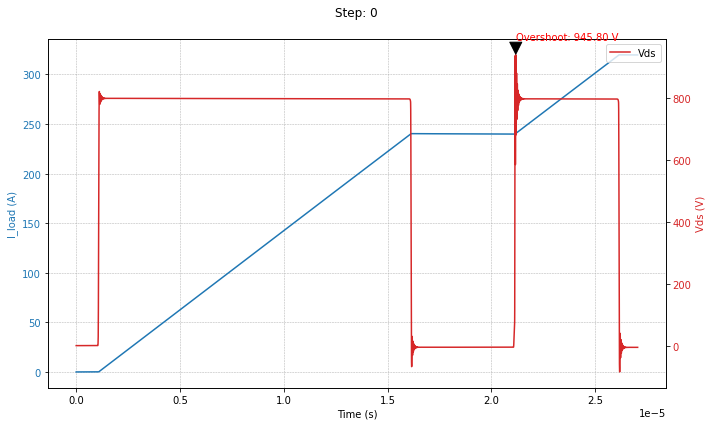

In [2]:
from PyLTSpice import RawRead

from matplotlib import pyplot as plt

LTR = RawRead("./temp/DPT_Test_Stand_HB_automate_70.raw")

print(LTR.get_trace_names())
print(LTR.get_raw_property())

I_load = LTR.get_trace("I(Loadind)")
x = LTR.get_trace('time')  # Gets the time axis
steps = LTR.get_steps()
V_high = LTR.get_trace("V(high)")
V_mid = LTR.get_trace("V(mid)")

import numpy as np

overshoots = []

for step in range(len(steps)):
    vds = V_high.get_wave(step) - V_mid.get_wave(step)
    t = x.get_wave(step)

    # Calculate overshoot: max(Vds) - steady-state value (assume last value is steady-state)
    steady_state = vds[-1]
    max_vds = np.max(vds)
    overshoot = max_vds - steady_state
    overshoots.append(overshoot)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    color1 = 'tab:blue'
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('I_load (A)', color=color1)
    ax1.plot(t, I_load.get_wave(step), color=color1, label='I_load')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

    ax2 = ax1.twinx()
    color2 = 'tab:red'
    ax2.set_ylabel('Vds (V)', color=color2)
    ax2.plot(t, vds, color=color2, label='Vds')
    ax2.tick_params(axis='y', labelcolor=color2)

    # Annotate overshoot on the plot
    ax2.annotate(f"Overshoot: {overshoot:.2f} V", xy=(t[np.argmax(vds)], max_vds),
                 xytext=(t[np.argmax(vds)], max_vds + 0.05 * max_vds),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=10, color='red')

    fig.suptitle(f"Step: {steps[step]}")
    fig.tight_layout()

# Print overshoot values for each step
for idx, ov in enumerate(overshoots):
    print(f"Step {steps[idx]}: Vds overshoot = {ov:.4f} V")


plt.legend()  # order a legend
plt.show()